# 🏏 Bangla Sports Sentiment Analysis
## Advanced Stacking Ensemble: RF + CNN + TNN → Logistic Regression Meta-Learner

---
**Pipeline Overview:**
1. Data Loading & EDA
2. Preprocessing & Feature Engineering
3. Base Model Training (RF, CNN, TNN)
4. Stacking Ensemble with Logistic Regression
5. Comprehensive Evaluation (Confusion Matrix, ROC-AUC, Learning Curves)
6. Accuracy Improvement Suggestions

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Section 1: Install & Import Libraries

In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow openpyxl imbalanced-learn -q

In [3]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling1D,
    LSTM, Bidirectional, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot Style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

print('✅ All libraries loaded successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   Random seed        : {SEED}')

✅ All libraries loaded successfully!
   TensorFlow version : 2.19.0
   Random seed        : 42


## 📂 Section 2: Data Loading

In [5]:
# ── Load dataset ──────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'

raw_df = pd.read_excel(DATA_PATH)

print('=' * 55)
print('         DATASET OVERVIEW')
print('=' * 55)
print(f'  Shape          : {raw_df.shape}')
print(f'  Columns        : {list(raw_df.columns)}')
print(f'  Memory usage   : {raw_df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('=' * 55)
raw_df.head(5)

         DATASET OVERVIEW
  Shape          : (82611, 3)
  Columns        : ['Comment ', 'Category', 'Cleaned_Text']
  Memory usage   : 29226.9 KB


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


In [6]:
# ── Inspect raw label distribution BEFORE mapping ────────────────────────────
print('Raw label value counts (before mapping):')
print(raw_df.iloc[:, 1].value_counts(dropna=False))
print()
print('Missing values per column:')
print(raw_df.isnull().sum())

Raw label value counts (before mapping):
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Missing values per column:
Comment           5
Category          0
Cleaned_Text    341
dtype: int64


## 🔍 Section 3: Exploratory Data Analysis (EDA)

In [7]:
# ── Build clean df for EDA ────────────────────────────────────────────────────
df = raw_df.copy()
df.columns = ['text', 'sentiment'] + list(df.columns[2:])   # rename first two
df['text']      = df['text'].astype(str).str.strip()
df['sentiment'] = df['sentiment'].astype(str).str.strip()

# Flexible label mapping (handles mixed case)
label_map = {}
for val in df['sentiment'].unique():
    if str(val).lower() in ['positive', '1', 'pos']:
        label_map[val] = 1
    elif str(val).lower() in ['negative', '0', 'neg']:
        label_map[val] = 0

df['label'] = df['sentiment'].map(label_map)
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

# Text-derived features for EDA
df['text_length']  = df['text'].str.len()
df['word_count']   = df['text'].str.split().str.len()
df['avg_word_len'] = df['text'].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)

print(f'Clean dataset shape: {df.shape}')
print(f'Label distribution :\n{df["label"].value_counts()}')

Clean dataset shape: (82611, 7)
Label distribution :
label
0    41355
1    41256
Name: count, dtype: int64


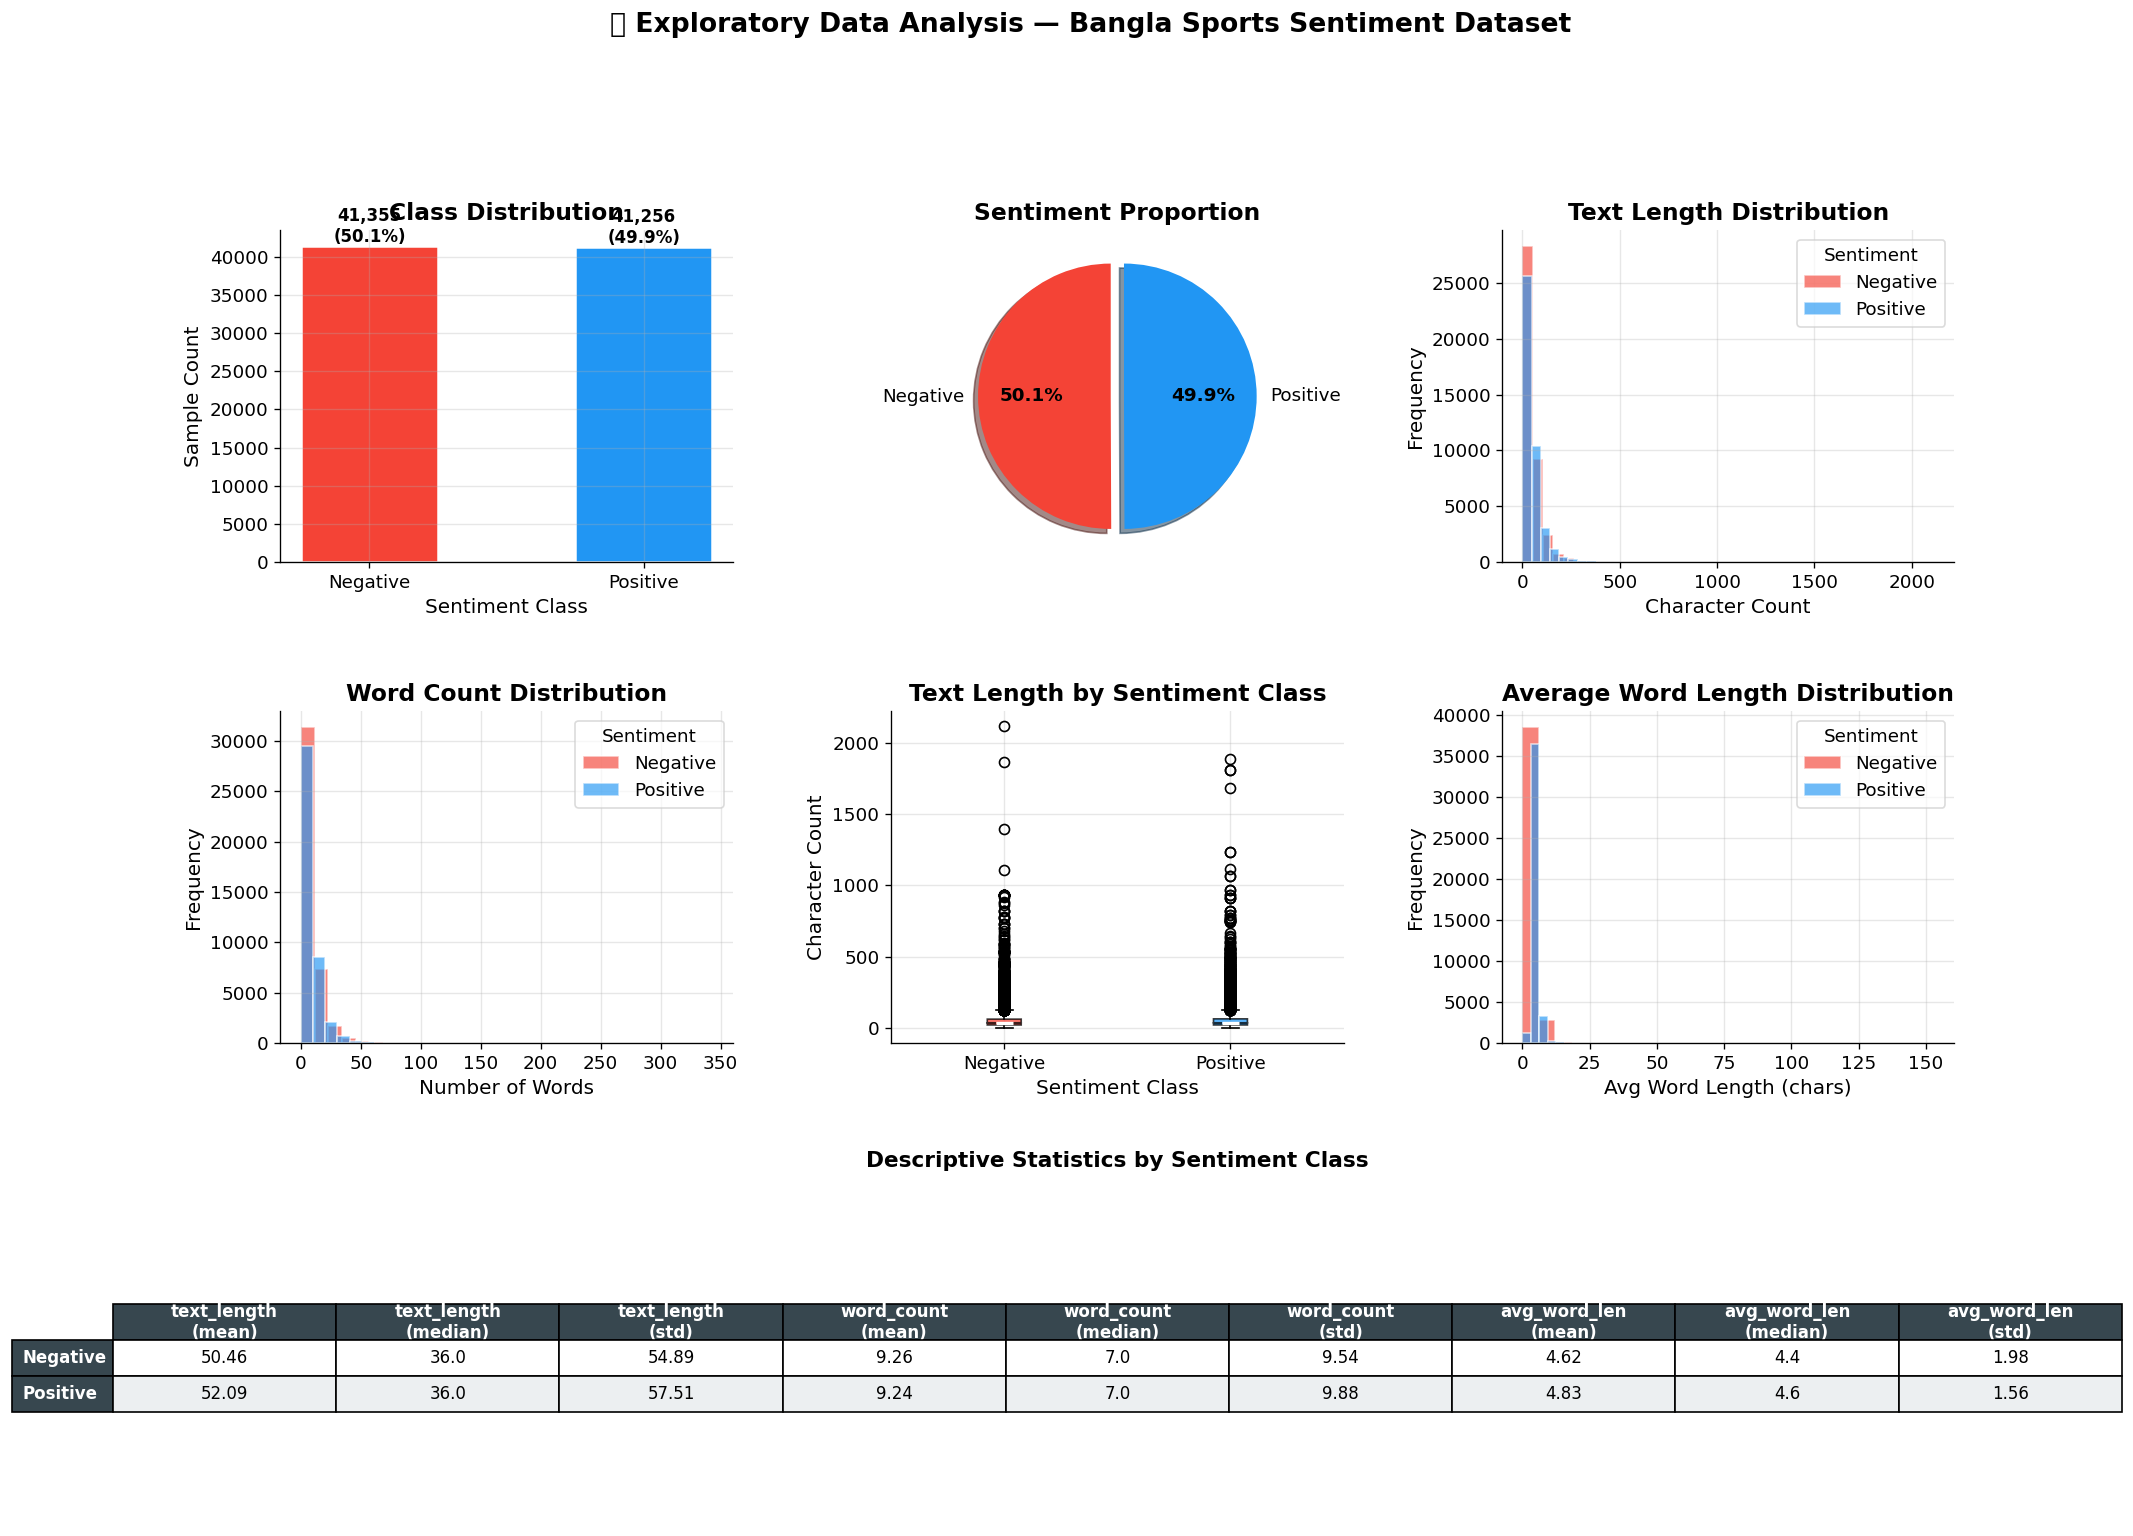

✅ EDA plots saved.


In [8]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

CLASS_LABELS = {0: 'Negative', 1: 'Positive'}
CLASS_COLORS = {0: PALETTE[1], 1: PALETTE[0]}

# ── 1. Class Distribution Bar ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts     = df['label'].value_counts().sort_index()
bar_colors = [CLASS_COLORS[i] for i in counts.index]
bars = ax1.bar([CLASS_LABELS[i] for i in counts.index], counts.values,
               color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_title('Class Distribution')
ax1.set_ylabel('Sample Count')
ax1.set_xlabel('Sentiment Class')

# ── 2. Pie Chart ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[CLASS_LABELS[i] for i in counts.index],
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=90,
    explode=[0.05] * len(counts),
    shadow=True,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Sentiment Proportion')

# ── 3. Text Length Distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for lbl, grp in df.groupby('label'):
    ax3.hist(grp['text_length'], bins=40, alpha=0.65,
             label=CLASS_LABELS[lbl], color=CLASS_COLORS[lbl], edgecolor='white')
ax3.set_title('Text Length Distribution')
ax3.set_xlabel('Character Count')
ax3.set_ylabel('Frequency')
ax3.legend(title='Sentiment', framealpha=0.7)

# ── 4. Word Count Distribution ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for lbl, grp in df.groupby('label'):
    ax4.hist(grp['word_count'], bins=30, alpha=0.65,
             label=CLASS_LABELS[lbl], color=CLASS_COLORS[lbl], edgecolor='white')
ax4.set_title('Word Count Distribution')
ax4.set_xlabel('Number of Words')
ax4.set_ylabel('Frequency')
ax4.legend(title='Sentiment', framealpha=0.7)

# ── 5. Box Plot – Text Length by Class ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
data_by_class = [df[df['label'] == lbl]['text_length'].values for lbl in sorted(df['label'].unique())]
bp = ax5.boxplot(data_by_class,
                 labels=[CLASS_LABELS[l] for l in sorted(df['label'].unique())],
                 patch_artist=True, notch=True, vert=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax5.set_title('Text Length by Sentiment Class')
ax5.set_xlabel('Sentiment Class')
ax5.set_ylabel('Character Count')

# ── 6. Average Word Length ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for lbl, grp in df.groupby('label'):
    ax6.hist(grp['avg_word_len'], bins=25, alpha=0.65,
             label=CLASS_LABELS[lbl], color=CLASS_COLORS[lbl], edgecolor='white')
ax6.set_title('Average Word Length Distribution')
ax6.set_xlabel('Avg Word Length (chars)')
ax6.set_ylabel('Frequency')
ax6.legend(title='Sentiment', framealpha=0.7)

# ── 7. Descriptive Stats Table ─────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')
stats = df.groupby('label')[['text_length', 'word_count', 'avg_word_len']].agg(['mean', 'median', 'std']).round(2)
stats.index = [CLASS_LABELS[i] for i in stats.index]
stats.columns = [f'{col[0]}\n({col[1]})' for col in stats.columns]
table = ax7.table(cellText=stats.values, rowLabels=stats.index,
                  colLabels=stats.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#ECEFF1' if row % 2 == 0 else '#FFFFFF')
ax7.set_title('Descriptive Statistics by Sentiment Class', fontsize=13, fontweight='bold', pad=15)

fig.suptitle('📊 Exploratory Data Analysis — Bangla Sports Sentiment Dataset',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ EDA plots saved.')

## ⚙️ Section 4: Preprocessing & Feature Engineering

In [9]:
import re
import string

def clean_text(text: str) -> str:
    """Lightweight Bangla-safe text cleaner."""
    text = str(text).strip()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

# ── Remove empty texts after cleaning ─────────────────────────────────────────
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

# ── Final feature & label arrays ──────────────────────────────────────────────
X = df['text_clean'].values
y = df['label'].values

# ── Stratified split: 70% train | 15% val | 15% test ─────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'Dataset size  : {len(X):,}')
print(f'Train         : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation    : {len(X_val):,}   ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test          : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)')

# ── Class weights for imbalanced data ─────────────────────────────────────────
classes = np.unique(y_train)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights_arr))
print(f'\nClass weights : {class_weight_dict}')

Dataset size  : 82,600
Train         : 57,820  (70.0%)
Validation    : 12,390   (15.0%)
Test          : 12,390   (15.0%)

Class weights : {np.int64(0): np.float64(0.9988943404049478), np.int64(1): np.float64(1.0011081099799155)}


In [10]:
# ── TF-IDF Vectorizer (for RF) ─────────────────────────────────────────────────
MAX_FEATURES  = 10000   # increased from 5000
NGRAM_RANGE   = (1, 2)  # unigrams + bigrams
MAX_SEQ_LEN   = 150     # increased from 100
VOCAB_SIZE    = 10000

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=True,       # log normalization
    min_df=2,                # ignore very rare terms
    strip_accents=None,      # preserve Bangla chars
    analyzer='char_wb'       # character n-grams work well for Bangla
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# ── Tokenizer (for CNN / TNN) ─────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f'TF-IDF feature matrix (train) : {X_train_tfidf.shape}')
print(f'Sequence matrix (train)        : {X_train_seq.shape}')
print(f'Vocabulary size                : {len(tokenizer.word_index):,}')

TF-IDF feature matrix (train) : (57820, 4501)
Sequence matrix (train)        : (57820, 150)
Vocabulary size                : 39,246


## 🌲 Section 5: Base Model 1 — Random Forest

In [11]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',   # handle imbalance
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train_tfidf, y_train)

rf_val_acc = accuracy_score(y_val, rf.predict(X_val_tfidf))
print(f'✅ RF  — Validation Accuracy: {rf_val_acc:.4f}')

# Stacking inputs
rf_pred_train = rf.predict_proba(X_train_tfidf)
rf_pred_val   = rf.predict_proba(X_val_tfidf)
rf_pred_test  = rf.predict_proba(X_test_tfidf)

Training Random Forest...
✅ RF  — Validation Accuracy: 0.8131


## 🧠 Section 6: Base Model 2 — CNN (Convolutional Neural Network)

In [12]:
EMBED_DIM  = 128
EPOCHS     = 20
BATCH_SIZE = 64

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

def build_cnn(vocab_size, embed_dim, seq_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=seq_len),
        SpatialDropout1D(0.3),
        Conv1D(256, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='CNN')
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn = build_cnn(VOCAB_SIZE, EMBED_DIM, MAX_SEQ_LEN)
cnn.summary()

cnn_history = cnn.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_seq, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

cnn_val_acc = cnn.evaluate(X_val_seq, y_val, verbose=0)[1]
print(f'\n✅ CNN — Validation Accuracy: {cnn_val_acc:.4f}')

cnn_pred_train = cnn.predict(X_train_seq, verbose=0)
cnn_pred_val   = cnn.predict(X_val_seq,   verbose=0)
cnn_pred_test  = cnn.predict(X_test_seq,  verbose=0)

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.7254 - loss: 0.5793 - val_accuracy: 0.7667 - val_loss: 0.5306 - learning_rate: 0.0010
Epoch 2/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8076 - loss: 0.4560 - val_accuracy: 0.7709 - val_loss: 0.5074 - learning_rate: 0.0010
Epoch 3/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8450 - loss: 0.3833 - val_accuracy: 0.7654 - val_loss: 0.5499 - learning_rate: 0.0010
Epoch 4/20
898/904 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8662 - loss: 0.3455
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8732 - loss: 0.3284 - val_accuracy: 0.7765 - val_loss: 0.6049 - learning_rate: 0.0010
Epoch 5/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9032 - loss: 0.2667 - val_accuracy: 0.7795 - val_loss: 0.6452 - learning_rate: 5.0000e-04
Epoch 6/20
902/904 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9075 - loss: 0.25

## 🔗 Section 7: Base Model 3 — TNN (Text Neural Network / MLP)

In [13]:
def build_tnn(vocab_size, embed_dim, seq_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=seq_len),
        SpatialDropout1D(0.25),
        GlobalAveragePooling1D(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ], name='TNN')
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tnn = build_tnn(VOCAB_SIZE, EMBED_DIM, MAX_SEQ_LEN)
tnn.summary()

tnn_history = tnn.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_seq, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

tnn_val_acc = tnn.evaluate(X_val_seq, y_val, verbose=0)[1]
print(f'\n✅ TNN — Validation Accuracy: {tnn_val_acc:.4f}')

tnn_pred_train = tnn.predict(X_train_seq, verbose=0)
tnn_pred_val   = tnn.predict(X_val_seq,   verbose=0)
tnn_pred_test  = tnn.predict(X_test_seq,  verbose=0)

Model: "TNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5055 - loss: 0.7254 - val_accuracy: 0.5223 - val_loss: 0.7085 - learning_rate: 0.0010
Epoch 2/20
898/904 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6325 - loss: 0.6567
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6785 - loss: 0.6177 - val_accuracy: 0.7230 - val_loss: 0.5619 - learning_rate: 0.0010
Epoch 3/20
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7616 - loss: 0.5144 - val_accuracy: 0.7347 - val_loss: 0.5397 - learning_rate: 5.0000e-04
Epoch 4/20
903/904 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7764 - loss: 0.4885
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7790 - loss: 0.4840 - val_accuracy: 0.7366 - val_loss: 0.5283 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1

## 🏗️ Section 8: Stacking Ensemble — Logistic Regression Meta-Learner

In [14]:
# ── Build stacking feature matrices ──────────────────────────────────────────
X_stack_train = np.column_stack([
    rf_pred_train[:, 1],
    cnn_pred_train.flatten(),
    tnn_pred_train.flatten()
])
X_stack_val = np.column_stack([
    rf_pred_val[:, 1],
    cnn_pred_val.flatten(),
    tnn_pred_val.flatten()
])
X_stack_test = np.column_stack([
    rf_pred_test[:, 1],
    cnn_pred_test.flatten(),
    tnn_pred_test.flatten()
])

# ── Meta-learner ──────────────────────────────────────────────────────────────
meta = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=SEED
)
meta.fit(X_stack_train, y_train)

# ── Predictions ────────────────────────────────────────────────────────────────
y_pred          = meta.predict(X_stack_test)
y_pred_proba    = meta.predict_proba(X_stack_test)[:, 1]

# Individual model predictions for comparison
rf_test_pred    = rf.predict(X_test_tfidf)
cnn_test_pred   = (cnn_pred_test.flatten() > 0.5).astype(int)
tnn_test_pred   = (tnn_pred_test.flatten() > 0.5).astype(int)

print('\n' + '='*55)
print('         ENSEMBLE RESULT')
print('='*55)
print(f'  Random Forest Accuracy     : {accuracy_score(y_test, rf_test_pred):.4f}')
print(f'  CNN Accuracy               : {accuracy_score(y_test, cnn_test_pred):.4f}')
print(f'  TNN Accuracy               : {accuracy_score(y_test, tnn_test_pred):.4f}')
print(f'  ──────────────────────────────────────')
print(f'  🏆 Stacking Ensemble        : {accuracy_score(y_test, y_pred):.4f}')
print('='*55)
print()
print('Classification Report (Stacking Ensemble):')
print(classification_report(y_test, y_pred,
                             target_names=['Negative', 'Positive'],
                             digits=4))


         ENSEMBLE RESULT
  Random Forest Accuracy     : 0.8090
  CNN Accuracy               : 0.7727
  TNN Accuracy               : 0.5218
  ──────────────────────────────────────
  🏆 Stacking Ensemble        : 0.8015

Classification Report (Stacking Ensemble):
              precision    recall  f1-score   support

    Negative     0.7913    0.8194    0.8051      6202
    Positive     0.8123    0.7835    0.7976      6188

    accuracy                         0.8015     12390
   macro avg     0.8018    0.8014    0.8014     12390
weighted avg     0.8018    0.8015    0.8014     12390



## 📊 Section 9: Confusion Matrix (All Models)

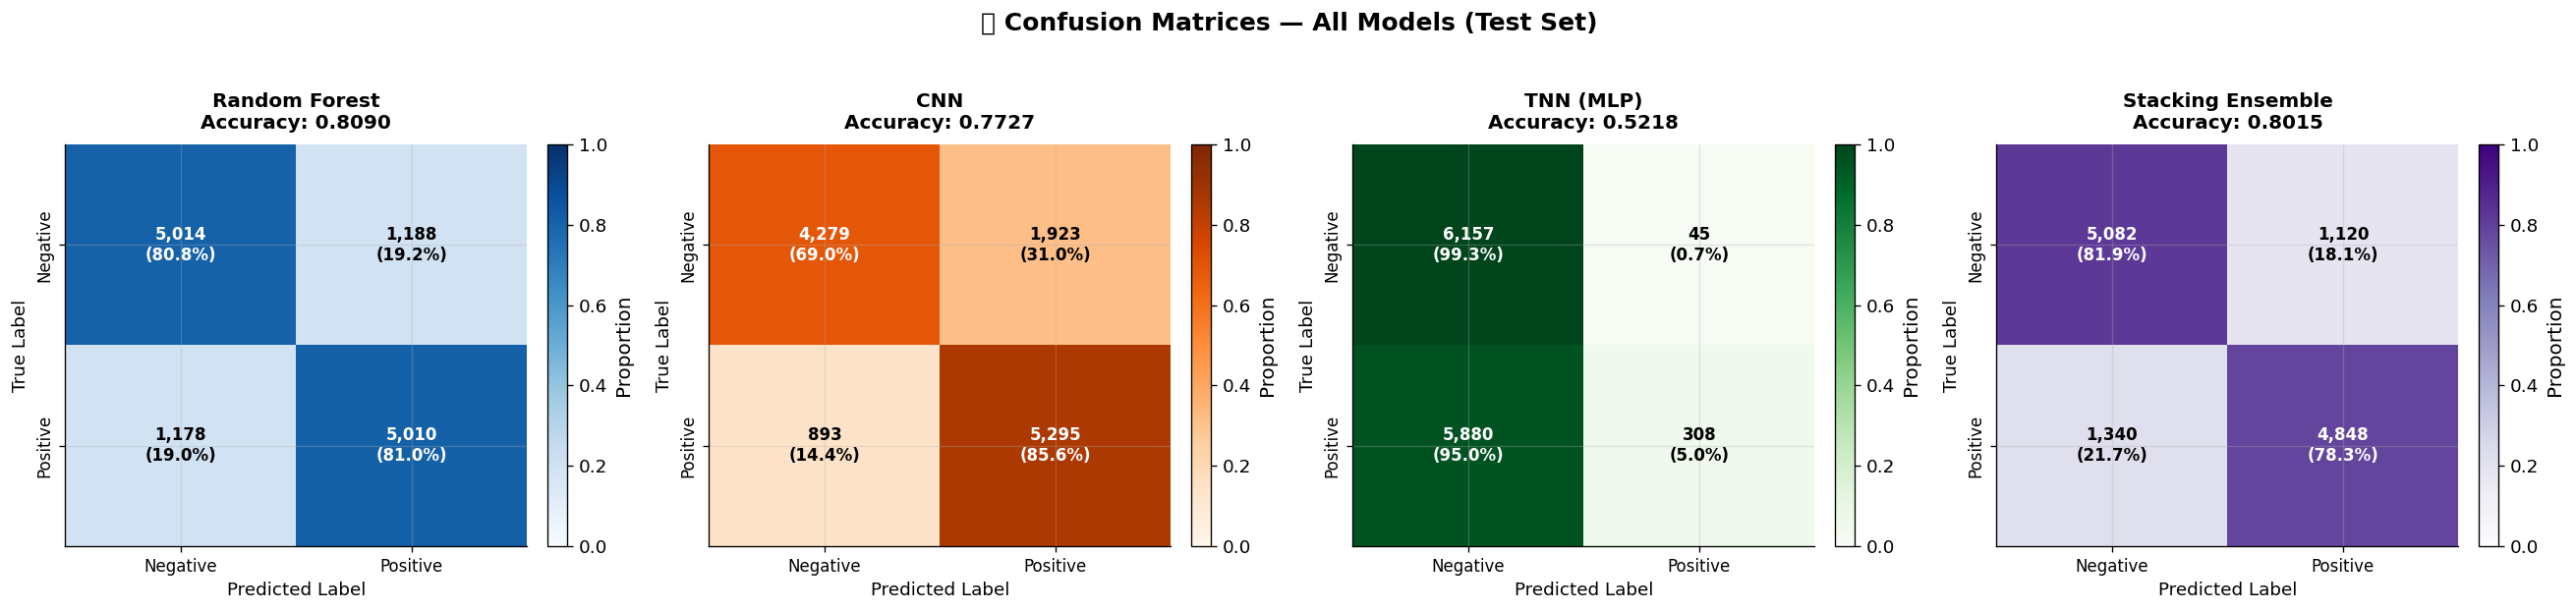

✅ Confusion matrices saved.


In [15]:
models_info = [
    ('Random Forest',       rf_test_pred),
    ('CNN',                 cnn_test_pred),
    ('TNN (MLP)',           tnn_test_pred),
    ('Stacking Ensemble',   y_pred),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
CLASS_NAMES = ['Negative', 'Positive']
CMAPS       = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, (model_name, preds), cmap in zip(axes, models_info, CMAPS):
    cm  = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds)

    # Normalize for color, display raw counts
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            bg_brightness = cm_norm[i, j]
            txt_color     = 'white' if bg_brightness > 0.5 else 'black'
            ax.text(j, i,
                    f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)',
                    ha='center', va='center',
                    color=txt_color, fontsize=10, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES, fontsize=10)
    ax.set_yticklabels(CLASS_NAMES, fontsize=10, rotation=90, va='center')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{model_name}\nAccuracy: {acc:.4f}', fontsize=12, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Proportion')

fig.suptitle('🔲 Confusion Matrices — All Models (Test Set)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Confusion matrices saved.')

## 📈 Section 10: ROC & AUC Curves

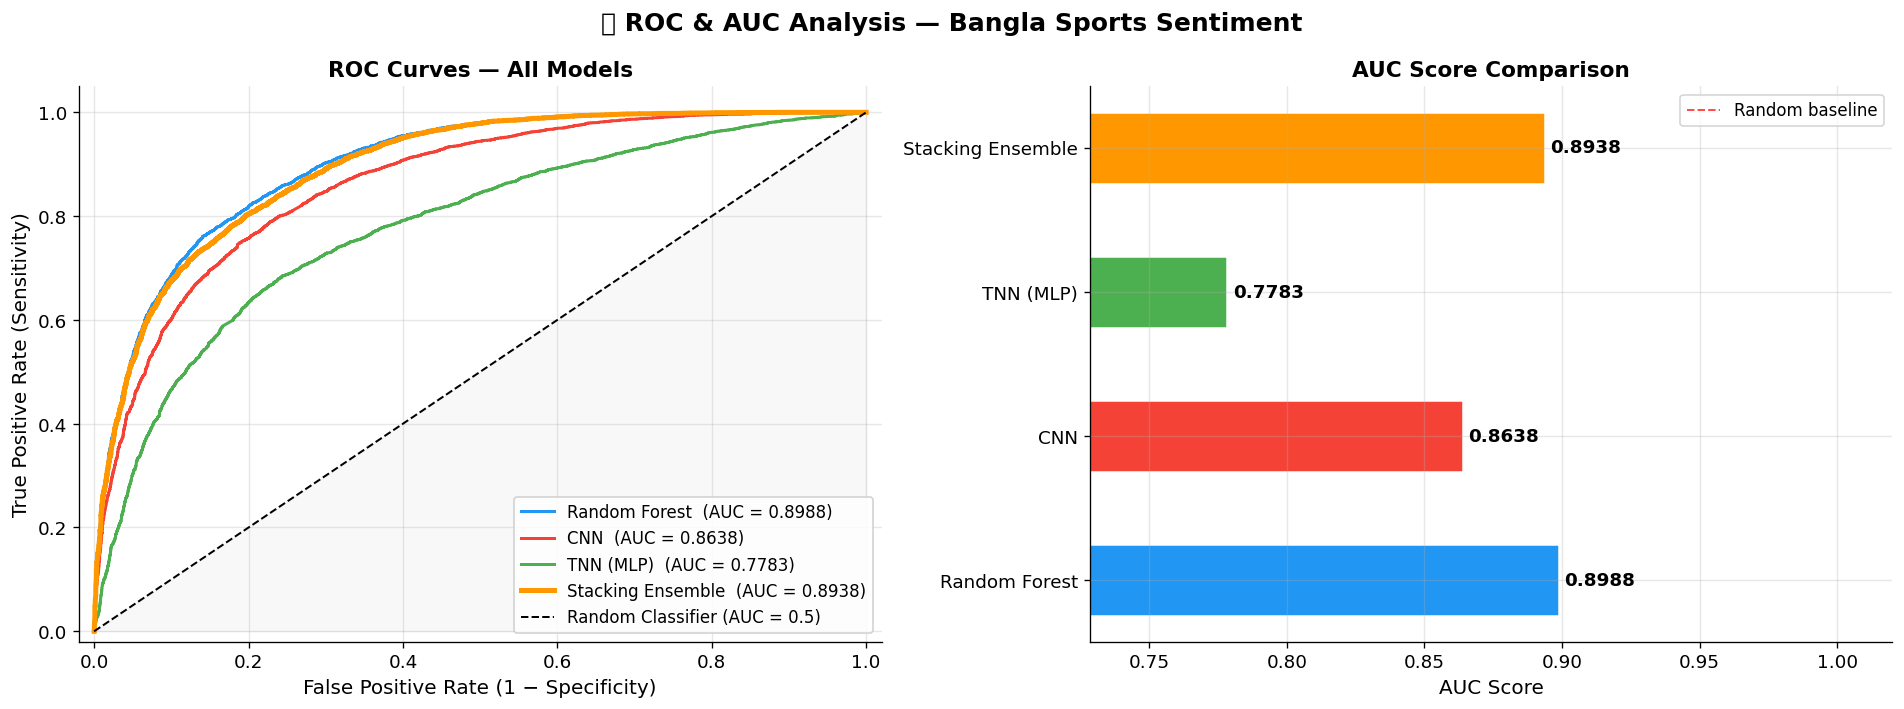

✅ ROC-AUC curves saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

roc_models = [
    ('Random Forest',     rf.predict_proba(X_test_tfidf)[:, 1],   PALETTE[0]),
    ('CNN',               cnn_pred_test.flatten(),                  PALETTE[1]),
    ('TNN (MLP)',         tnn_pred_test.flatten(),                  PALETTE[2]),
    ('Stacking Ensemble', y_pred_proba,                             PALETTE[3]),
]

# ── Left: Individual ROC curves ────────────────────────────────────────────────
ax = axes[0]
for name, proba, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    lw = 3 if name == 'Stacking Ensemble' else 1.8
    ax.plot(fpr, tpr, lw=lw, color=color, label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.85)

# ── Right: AUC bar chart ──────────────────────────────────────────────────────
ax2 = axes[1]
names  = [n for n, _, _ in roc_models]
aucs   = [auc(*roc_curve(y_test, p)[:2]) for _, p, _ in roc_models]
colors = [c for _, _, c in roc_models]

bars = ax2.barh(names, aucs, color=colors, edgecolor='white', linewidth=1.5, height=0.5)
for bar, val in zip(bars, aucs):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left', fontweight='bold', fontsize=11)
ax2.set_xlim([min(aucs) - 0.05, 1.02])
ax2.set_xlabel('AUC Score', fontsize=12)
ax2.set_title('AUC Score Comparison', fontsize=13)
ax2.axvline(x=0.5, color='red', linestyle='--', lw=1.2, alpha=0.7, label='Random baseline')
ax2.legend(fontsize=10)

fig.suptitle('📈 ROC & AUC Analysis — Bangla Sports Sentiment',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_auc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ ROC-AUC curves saved.')

## 📉 Section 11: Learning Curves (Training History — CNN & TNN)

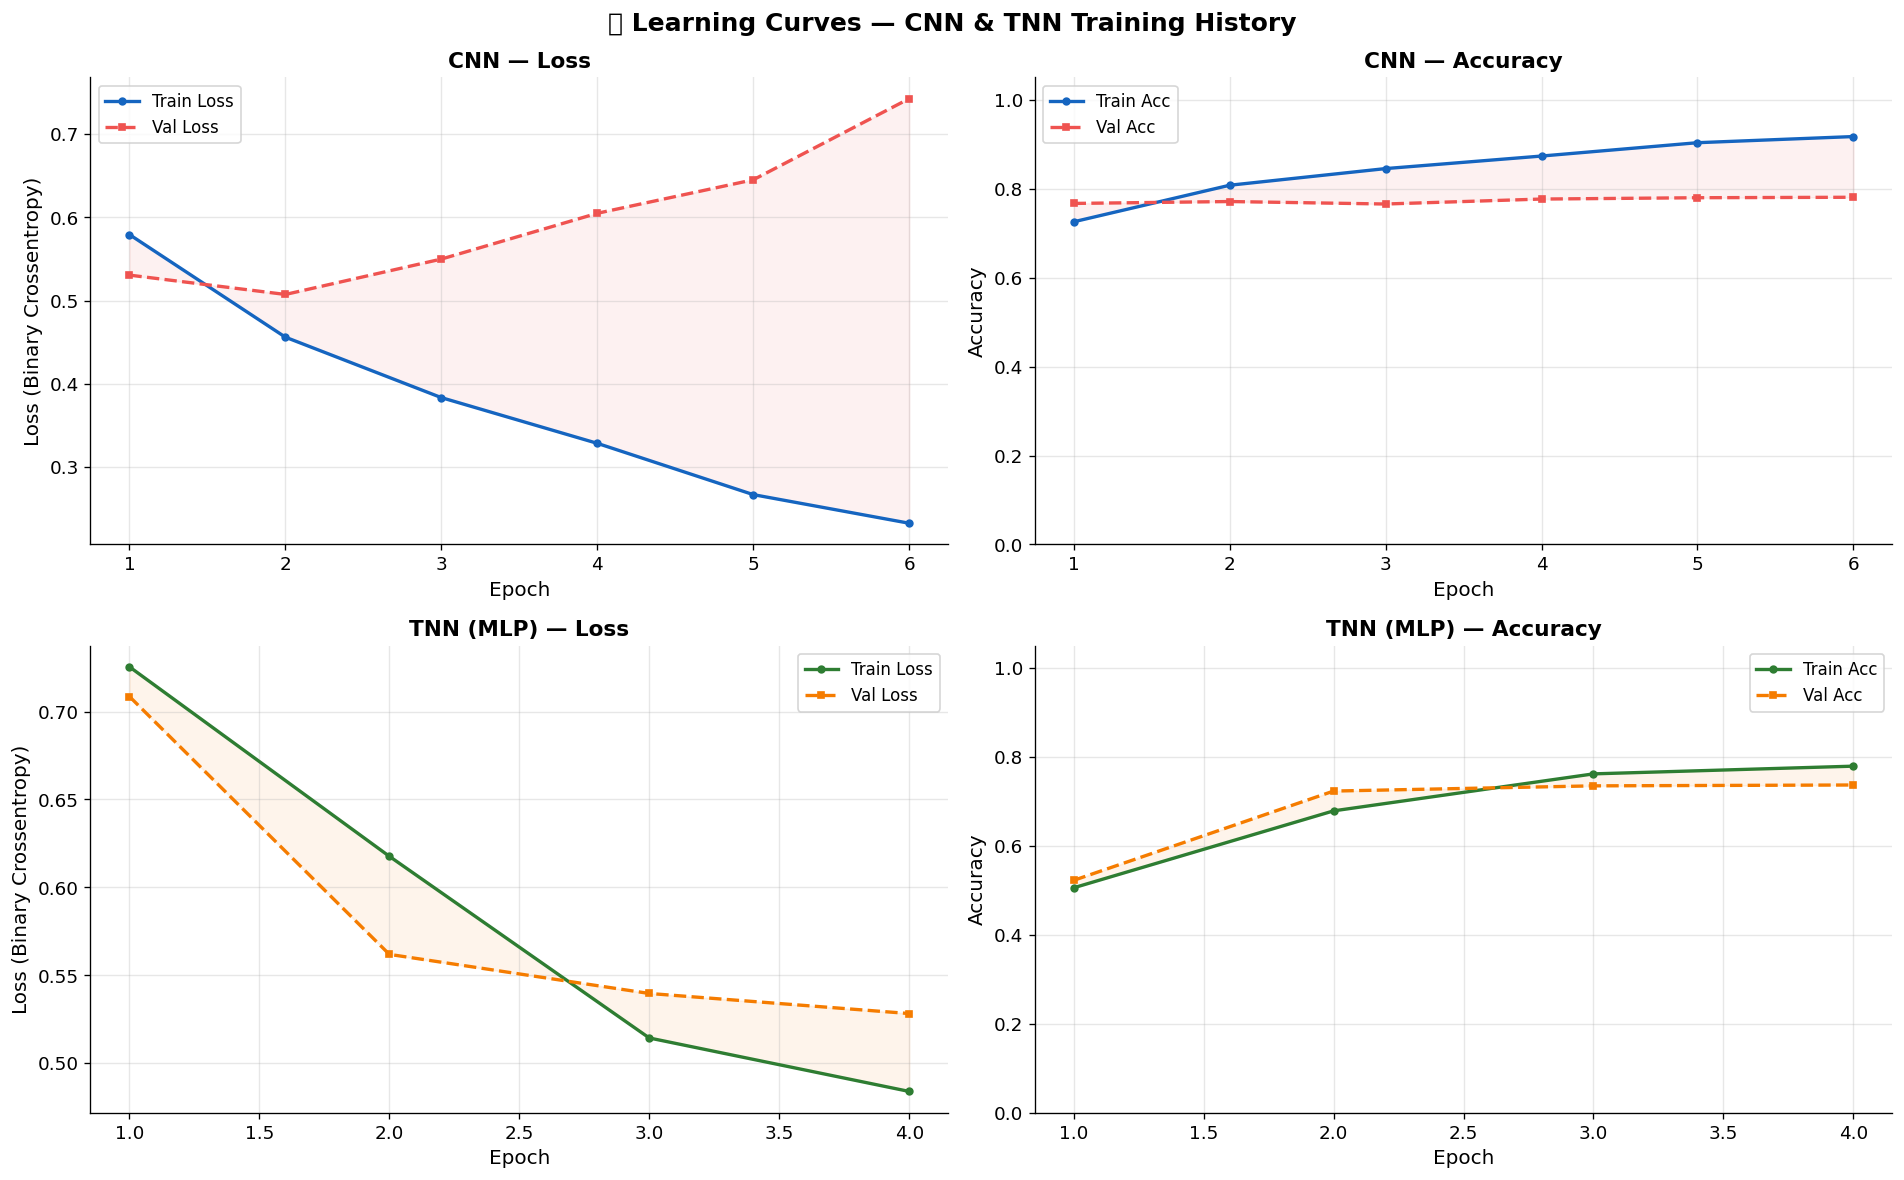

✅ Learning curves saved.


In [17]:
def plot_keras_history(history, model_name, ax_loss, ax_acc, color_train, color_val):
    epochs_ran = range(1, len(history.history['loss']) + 1)

    ax_loss.plot(epochs_ran, history.history['loss'],
                 color=color_train, lw=2, marker='o', ms=4, label='Train Loss')
    ax_loss.plot(epochs_ran, history.history['val_loss'],
                 color=color_val,   lw=2, marker='s', ms=4, linestyle='--', label='Val Loss')
    ax_loss.fill_between(epochs_ran, history.history['loss'], history.history['val_loss'],
                          alpha=0.08, color=color_val)
    ax_loss.set_title(f'{model_name} — Loss', fontsize=13)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss (Binary Crossentropy)')
    ax_loss.legend(fontsize=10)

    ax_acc.plot(epochs_ran, history.history['accuracy'],
                color=color_train, lw=2, marker='o', ms=4, label='Train Acc')
    ax_acc.plot(epochs_ran, history.history['val_accuracy'],
                color=color_val,   lw=2, marker='s', ms=4, linestyle='--', label='Val Acc')
    ax_acc.fill_between(epochs_ran, history.history['accuracy'], history.history['val_accuracy'],
                         alpha=0.08, color=color_val)
    ax_acc.set_title(f'{model_name} — Accuracy', fontsize=13)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=10)
    ax_acc.set_ylim([0, 1.05])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_keras_history(cnn_history, 'CNN',
                   axes[0, 0], axes[0, 1],
                   color_train='#1565C0', color_val='#EF5350')
plot_keras_history(tnn_history, 'TNN (MLP)',
                   axes[1, 0], axes[1, 1],
                   color_train='#2E7D32', color_val='#F57C00')

fig.suptitle('📉 Learning Curves — CNN & TNN Training History',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Learning curves saved.')

## 🧪 Section 12: RF Learning Curve (sklearn)

In [ ]:
from sklearn.model_selection import learning_curve

rf_lc = RandomForestClassifier(
    n_estimators=100, max_features='sqrt',
    class_weight='balanced', n_jobs=-1, random_state=SEED
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_lc, X_train_tfidf, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#1565C0', lw=2.5, ms=7,
        label='Training Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#1565C0')
ax.plot(train_sizes, val_mean, 's--', color='#EF5350', lw=2.5, ms=7,
        label='Cross-Validation Accuracy')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#EF5350')

# Annotate gap
gap = train_mean[-1] - val_mean[-1]
ax.annotate(
    f'Gap: {gap:.3f}\n({"Overfitting" if gap > 0.05 else "Good Fit"})',
    xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
    xytext=(-80, 0), textcoords='offset points',
    fontsize=11, color='purple', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='purple', lw=1.5)
)

ax.set_title('Random Forest — Learning Curve (5-Fold CV)', fontsize=14)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim([0.5, 1.05])

plt.tight_layout()
plt.savefig('rf_learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ RF learning curve saved.')

## 📋 Section 13: Full Classification Reports

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

all_preds = [
    ('Random Forest',     rf_test_pred),
    ('CNN',               cnn_test_pred),
    ('TNN (MLP)',         tnn_test_pred),
    ('Stacking Ensemble', y_pred),
]

for name, preds in all_preds:
    print('─' * 60)
    print(f'  MODEL: {name}')
    print('─' * 60)
    print(classification_report(
        y_test, preds,
        target_names=['Negative', 'Positive'],
        digits=4
    ))

# ── Summary Table ─────────────────────────────────────────────────────────────
summary = []
for name, preds in all_preds:
    from sklearn.metrics import f1_score, precision_score, recall_score
    summary.append({
        'Model':      name,
        'Accuracy':   f'{accuracy_score(y_test, preds):.4f}',
        'Precision':  f'{precision_score(y_test, preds, average="weighted"):.4f}',
        'Recall':     f'{recall_score(y_test, preds, average="weighted"):.4f}',
        'F1-Score':   f'{f1_score(y_test, preds, average="weighted"):.4f}',
        'AUC':        f'{roc_auc_score(y_test, roc_models[[n for n,_,_ in roc_models].index(name)][1]):.4f}'
                     if name in [n for n,_,_ in roc_models] else '-'
    })

summary_df = pd.DataFrame(summary)
print('\n' + '='*65)
print('         📊 MODEL COMPARISON SUMMARY')
print('='*65)
print(summary_df.to_string(index=False))

In [ ]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
metrics_data = {}
from sklearn.metrics import f1_score, precision_score, recall_score
for name, preds in all_preds:
    metrics_data[name] = {
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall':    recall_score(y_test, preds, average='weighted'),
        'F1-Score':  f1_score(y_test, preds, average='weighted'),
    }

metrics_df = pd.DataFrame(metrics_data).T
metric_names = metrics_df.columns.tolist()

x     = np.arange(len(metrics_df.index))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metric_names, PALETTE)):
    bars = ax.bar(x + i * width, metrics_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0, 1.1])
ax.set_title('📊 Model Performance Comparison — All Metrics', fontsize=14)
ax.legend(loc='lower right', fontsize=10, framealpha=0.85)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Comparison chart saved.')

## 🔑 Section 14: Feature Importance — Random Forest

In [ ]:
importances = rf.feature_importances_
feature_names = tfidf.get_feature_names_out()

top_n = 25
top_idx = np.argsort(importances)[::-1][:top_n]
top_features = feature_names[top_idx]
top_scores   = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
colors  = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
bars    = ax.barh(range(top_n), top_scores[::-1], color=colors[::-1], edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features[::-1], fontsize=10)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'🔑 Top {top_n} Important Features — Random Forest', fontsize=14)

for bar, score in zip(bars, top_scores[::-1]):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{score:.5f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Feature importance chart saved.')

## 🎯 Section 15: Meta-Learner Weights & Stacking Analysis

In [ ]:
base_names    = ['Random Forest', 'CNN', 'TNN (MLP)']
meta_coef_abs = np.abs(meta.coef_[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Coefficient bar ───────────────────────────────────────────────────────────
axes[0].bar(base_names, meta_coef_abs, color=PALETTE[:3], edgecolor='white', width=0.4)
for i, (name, val) in enumerate(zip(base_names, meta_coef_abs)):
    axes[0].text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')
axes[0].set_title('Meta-Learner Coefficients\n(Absolute Value)', fontsize=13)
axes[0].set_ylabel('|Coefficient|')
axes[0].set_ylim([0, max(meta_coef_abs) * 1.3])

# ── Prediction correlation heatmap ────────────────────────────────────────────
stack_df = pd.DataFrame(X_stack_test, columns=base_names)
corr     = stack_df.corr()
mask     = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=axes[1], annot=True, fmt='.4f', cmap='coolwarm',
            center=0, square=True, linewidths=2,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Base Model Prediction Correlations\n(Test Set)', fontsize=13)

fig.suptitle('🎯 Stacking Ensemble Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('stacking_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Stacking analysis saved.')

## ✅ Section 16: Overfitting & Underfitting Diagnostics

In [ ]:
# ── Final train vs test accuracy for all models ────────────────────────────────
diag_models = [
    ('Random Forest', accuracy_score(y_train, rf.predict(X_train_tfidf)),
                      accuracy_score(y_test,  rf_test_pred)),
    ('CNN',           cnn.evaluate(X_train_seq, y_train, verbose=0)[1],
                      cnn.evaluate(X_test_seq,  y_test,  verbose=0)[1]),
    ('TNN (MLP)',     tnn.evaluate(X_train_seq, y_train, verbose=0)[1],
                      tnn.evaluate(X_test_seq,  y_test,  verbose=0)[1]),
    ('Stacking',      accuracy_score(y_train, meta.predict(X_stack_train)),
                      accuracy_score(y_test,  y_pred)),
]

names_d  = [m[0] for m in diag_models]
train_ac = [m[1] for m in diag_models]
test_ac  = [m[2] for m in diag_models]
gaps     = [tr - te for tr, te in zip(train_ac, test_ac)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Grouped bar: train vs test ────────────────────────────────────────────────
x     = np.arange(len(names_d))
width = 0.3
b1 = axes[0].bar(x - width/2, train_ac, width, label='Train Accuracy', color='#1565C0', alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x + width/2, test_ac,  width, label='Test Accuracy',  color='#EF5350', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names_d, fontsize=11)
axes[0].set_ylim([0, 1.12])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy per Model', fontsize=13)
axes[0].legend(fontsize=10)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── Gap bar (overfit detector) ─────────────────────────────────────────────────
gap_colors = ['#EF5350' if g > 0.05 else ('#FF9800' if g > 0.02 else '#4CAF50') for g in gaps]
axes[1].bar(names_d, gaps, color=gap_colors, edgecolor='white', width=0.4)
axes[1].axhline(y=0.05, color='red', linestyle='--', lw=1.5, label='Overfit threshold (0.05)')
axes[1].axhline(y=0.02, color='orange', linestyle='--', lw=1.5, label='Warning threshold (0.02)')
axes[1].axhline(y=0.0,  color='black', linestyle='-',  lw=0.8)
axes[1].set_ylabel('Train Accuracy − Test Accuracy')
axes[1].set_title('Generalization Gap (Overfit Detector)', fontsize=13)
axes[1].legend(fontsize=9)
for i, (name, gap) in enumerate(zip(names_d, gaps)):
    label = '🔴 Overfit' if gap > 0.05 else ('🟠 Warning' if gap > 0.02 else '🟢 OK')
    axes[1].text(i, gap + 0.003, label, ha='center', fontsize=9, fontweight='bold')

fig.suptitle('✅ Overfitting & Underfitting Diagnostics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('overfit_diagnostics.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Overfitting diagnostics saved.')

## 🚀 Section 17: Suggestions for Improving Accuracy

Based on the diagnostics above, here are concrete improvement strategies:

---

### 🔤 1. Better Text Representations
| Method | Expected Gain | Effort |
|---|---|---|
| **Bangla BERT / BanglaBERT** (pretrained transformer) | +5–15% | Medium |
| **FastText embeddings** (Bangla Wikipedia) | +3–8% | Low |
| **Character + Word n-gram TF-IDF fusion** | +2–5% | Low |

### 🧹 2. Smarter Preprocessing
- **Bangla stopword removal** (use bnlp-toolkit library)
- **Bangla stemming / lemmatization** (reduces vocabulary noise)
- **Emoji / punctuation sentiment features** (can carry strong signal)

### 🏗️ 3. Better Architectures
- **BiLSTM or Bi-GRU** — bidirectional context captures Bangla sentence structure better than CNN
- **CNN + BiLSTM hybrid** — local + global features
- **Transformer fine-tuning** — `sagorsarker/bangla-bert-base` on HuggingFace

### 📈 4. Training Improvements
- **Increase epochs** with early stopping — let models converge fully
- **Label smoothing** (reduces overconfident predictions)
- **Mixup augmentation** for text sequences
- **Cross-validation on stacking** (use out-of-fold predictions for training meta-learner to prevent data leakage)

### 🎯 5. Ensemble Upgrades
- Replace LR meta-learner with **XGBoost or LightGBM**
- Add **SVM with RBF kernel** as an additional base model
- Use **Optuna** for hyperparameter optimization
- **Temperature scaling** for better probability calibration

### ⚠️ 6. Overfitting Prevention Checklist
- ✅ Dropout layers (already added)
- ✅ L2 regularization (already added)
- ✅ BatchNormalization (already added)
- ✅ EarlyStopping (already added)
- ✅ ReduceLROnPlateau (already added)
- ⬜ **Data augmentation** — back-translation or synonym replacement
- ⬜ **More training data** — the most reliable cure

---
> 💡 **Quick Win:** Try `sagorsarker/bangla-bert-base` from HuggingFace Transformers — fine-tuning even for 3 epochs typically outperforms all non-transformer approaches on Bangla NLP tasks.

In [ ]:
print('='*65)
print('         🏆 FINAL RESULTS SUMMARY')
print('='*65)
for name, preds in all_preds:
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f'  {name:<25} Acc={acc:.4f}  F1={f1:.4f}')
print('='*65)
print()
print('Plots saved:')
for f in ['eda_overview.png', 'confusion_matrices.png', 'roc_auc_curves.png',
          'learning_curves.png', 'rf_learning_curve.png', 'model_comparison.png',
          'feature_importance.png', 'stacking_analysis.png', 'overfit_diagnostics.png']:
    print(f'  ✅ {f}')